# Image Caption Generator v2 — InceptionV3 + LSTM (Improved)

An upgraded image captioning pipeline trained on **Flickr8k**, built for Kaggle.

**Improvements over the original VGG16 + LSTM version:**
- **InceptionV3** backbone instead of VGG16 → faster feature extraction, smaller feature vectors (2048-d vs 4096-d), better GPU utilization
- **Mixed precision training** (`float16`) for faster training on Kaggle's T4/P100 GPUs
- **tf.data pipeline** instead of a Python generator → much faster batch loading, no GIL bottleneck
- **Bidirectional LSTM + extra Dense layers + BatchNorm** for stronger language modeling, plus label smoothing in the loss
- **Learning rate scheduling + EarlyStopping + ModelCheckpoint** → no more "guess the right number of epochs"
- **Beam search decoding** alongside greedy decoding → noticeably better captions, with a toggle for both
- **Richer evaluation**: BLEU-1 through BLEU-4 (with smoothing), plus METEOR
- **Clean, modular code** — config block at the top, reusable functions, all paths/hyperparameters in one place
- **Train/val/test split** (not just train/test) so EarlyStopping has a proper validation signal

> Runtime: with a Kaggle GPU (T4 x2 or P100) enabled, feature extraction takes ~10-15 min and training ~25-40 min for 30 epochs (with early stopping likely cutting it shorter).


## 1. Setup & Configuration

Make sure **GPU is enabled** in this Kaggle notebook: `Settings → Accelerator → GPU T4 x2` (or P100).

Add the dataset via `+ Add Input` → search **"flickr8k"** (`adityajn105/flickr8k`) and attach it.


In [1]:
import os
import re
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Bidirectional, Embedding, Dropout,
    BatchNormalization, Add, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


2026-06-28 12:01:24.650042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782648084.836130      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782648084.895465      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782648085.338992      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782648085.339040      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782648085.339042      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# ----------------------- CONFIG -----------------------
class CFG:
    BASE_DIR = '/kaggle/input/datasets/adityajn105/flickr8k'          # dataset root (adjust if your dataset slug differs)
    WORKING_DIR = '/kaggle/working'

    IMG_SIZE = (299, 299)                         # InceptionV3's native input size
    FEATURE_DIM = 2048                            # InceptionV3 pooled feature size

    EMBED_DIM = 256
    LSTM_UNITS = 256
    DROPOUT = 0.4

    BATCH_SIZE = 64
    EPOCHS = 30
    LEARNING_RATE = 1e-3
    LABEL_SMOOTHING = 0.1

    VAL_SPLIT = 0.10                              # fraction of images for validation
    TEST_SPLIT = 0.10                             # fraction of images for test

    USE_MIXED_PRECISION = True
    SEED = 42

    BEAM_WIDTH = 3                                # for beam search decoding

os.makedirs(CFG.WORKING_DIR, exist_ok=True)

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

if CFG.USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())


Mixed precision enabled: <DTypePolicy "mixed_float16">


## 2. Extract Image Features with InceptionV3

InceptionV3 (pretrained on ImageNet) is used purely as a fixed feature extractor — we strip the
classification head and pool its output into a single 2048-d vector per image. This is faster
than VGG16 and produces a more compact, information-dense representation.

Features are cached to disk (`features.pkl`) so this expensive step only ever needs to run once.


In [6]:
def build_feature_extractor():
    base = InceptionV3(weights='imagenet', include_top=False, pooling='avg')
    return Model(inputs=base.input, outputs=base.output)

feature_model = build_feature_extractor()
feature_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, None,      │        864 │ input_layer_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, None,      │      9,216 │ activation_94[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, None,      │     18,432 │ activation_95[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, None,      │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, None,      │      5,120 │ max_pooling2d_4[… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, None,      │    138,240 │ activation_97[0]… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, None,      │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [7]:
def load_and_preprocess_image(img_path):
    image = load_img(img_path, target_size=CFG.IMG_SIZE)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    return image


def extract_features(image_dir, model, batch_size=64):
    """Extract features in batches (much faster than one-image-at-a-time predict calls)."""
    img_names = sorted(os.listdir(image_dir))
    features = {}

    for i in tqdm(range(0, len(img_names), batch_size), desc="Extracting features"):
        batch_names = img_names[i:i + batch_size]
        batch_imgs = []
        for name in batch_names:
            path = os.path.join(image_dir, name)
            batch_imgs.append(load_and_preprocess_image(path)[0])
        batch_imgs = np.stack(batch_imgs, axis=0)

        batch_feats = model.predict(batch_imgs, verbose=0)

        for name, feat in zip(batch_names, batch_feats):
            image_id = name.split('.')[0]
            features[image_id] = feat

    return features


FEATURES_PATH = os.path.join(CFG.WORKING_DIR, 'features.pkl')

if os.path.exists(FEATURES_PATH):
    print("Loading cached features...")
    with open(FEATURES_PATH, 'rb') as f:
        features = pickle.load(f)
else:
    print("Extracting features from scratch (this runs once)...")
    image_dir = os.path.join(CFG.BASE_DIR, 'Images')
    features = extract_features(image_dir, feature_model, batch_size=CFG.BATCH_SIZE)
    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(features, f)

print(f"Extracted features for {len(features)} images.")


Extracting features from scratch (this runs once)...


Extracting features:   0%|          | 0/127 [00:00<?, ?it/s]

I0000 00:00:1782648370.223507     129 service.cc:152] XLA service 0x7ff24c256a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782648370.223549     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782648370.223553     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782648371.491766     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782648380.358578     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Extracted features for 8091 images.


## 3. Load & Clean Captions


In [8]:
with open(os.path.join(CFG.BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)  # skip header
    captions_doc = f.read()

mapping = {}
for line in tqdm(captions_doc.strip().split('\n'), desc="Parsing captions"):
    tokens = line.split(',')
    if len(tokens) < 2:
        continue
    image_id, caption = tokens[0], ",".join(tokens[1:])
    image_id = image_id.split('.')[0]
    mapping.setdefault(image_id, []).append(caption)

print(f"Images with captions: {len(mapping)}")


Parsing captions:   0%|          | 0/40455 [00:00<?, ?it/s]

Images with captions: 8091


In [9]:
def clean_caption(caption: str) -> str:
    caption = caption.lower()
    caption = re.sub(r'[^a-z\s]', '', caption)   # keep only letters and spaces
    caption = re.sub(r'\s+', ' ', caption).strip()
    words = [w for w in caption.split() if len(w) > 1]
    return 'startseq ' + ' '.join(words) + ' endseq'


def clean_all_captions(mapping):
    for key, caps in mapping.items():
        mapping[key] = [clean_caption(c) for c in caps]


print("Before cleaning:", mapping[list(mapping.keys())[0]][0])
clean_all_captions(mapping)
print("After cleaning: ", mapping[list(mapping.keys())[0]][0])


Before cleaning: A child in a pink dress is climbing up a set of stairs in an entry way .
After cleaning:  startseq child in pink dress is climbing up set of stairs in an entry way endseq


In [10]:
all_captions = [c for caps in mapping.values() for c in caps]
print("Total captions:", len(all_captions))
print("Sample:", all_captions[:3])


Total captions: 40455
Sample: ['startseq child in pink dress is climbing up set of stairs in an entry way endseq', 'startseq girl going into wooden building endseq', 'startseq little girl climbing into wooden playhouse endseq']


## 4. Tokenize & Compute Vocabulary Stats


In [11]:
tokenizer = Tokenizer(oov_token='<unk>')
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

print("Vocabulary size:", vocab_size)
print("Max caption length:", max_length)

with open(os.path.join(CFG.WORKING_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)


Vocabulary size: 8769
Max caption length: 34


## 5. Train / Validation / Test Split

Unlike a simple 90/10 train/test split, we hold out a separate **validation** set so that
`EarlyStopping` and `ReduceLROnPlateau` have a genuine, unseen-during-training signal to act on.


In [12]:
image_ids = list(mapping.keys())
random.shuffle(image_ids)

n = len(image_ids)
n_test = int(n * CFG.TEST_SPLIT)
n_val = int(n * CFG.VAL_SPLIT)

test_ids = image_ids[:n_test]
val_ids = image_ids[n_test:n_test + n_val]
train_ids = image_ids[n_test + n_val:]

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")


Train: 6473 | Val: 809 | Test: 809


## 6. tf.data Input Pipeline

Instead of a hand-rolled Python generator (which is single-threaded and GIL-bound), we build a
`tf.data.Dataset` that expands each image into its `(input_sequence_so_far, next_word)` training
pairs and lets TensorFlow handle batching, shuffling, and prefetching on background threads —
this alone is typically a large speedup on Kaggle GPUs which are often starved waiting on the
CPU to feed batches.


In [13]:
def make_sequences(image_ids, mapping, tokenizer, max_length):
    """Expand each caption into (image_id, input_seq, next_word) training examples."""
    img_id_list, in_seqs, out_words = [], [], []

    for key in image_ids:
        for caption in mapping[key]:
            seq = tokenizer.texts_to_sequences([caption])[0]
            for i in range(1, len(seq)):
                in_seq, out_word = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                img_id_list.append(key)
                in_seqs.append(in_seq)
                out_words.append(out_word)

    return img_id_list, np.array(in_seqs), np.array(out_words)


print("Building training sequences...")
train_img_ids, train_in_seqs, train_out_words = make_sequences(train_ids, mapping, tokenizer, max_length)
print("Building validation sequences...")
val_img_ids, val_in_seqs, val_out_words = make_sequences(val_ids, mapping, tokenizer, max_length)

print(f"Train examples: {len(train_out_words)} | Val examples: {len(val_out_words)}")


Building training sequences...
Building validation sequences...
Train examples: 331009 | Val examples: 41215


In [14]:
def build_dataset(img_ids, in_seqs, out_words, features, batch_size, shuffle=True):
    img_feats = np.stack([features[i] for i in img_ids]).astype('float32')
    in_seqs = in_seqs.astype('int32')
    out_words = out_words.astype('int32')

    ds = tf.data.Dataset.from_tensor_slices(((img_feats, in_seqs), out_words))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=CFG.SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset(train_img_ids, train_in_seqs, train_out_words, features, CFG.BATCH_SIZE, shuffle=True)
val_ds = build_dataset(val_img_ids, val_in_seqs, val_out_words, features, CFG.BATCH_SIZE, shuffle=False)


## 7. Model Architecture

Compared to the original single `LSTM(256)` + plain merge model, this version adds:
- A **Bidirectional LSTM** for the text branch (captures context from both directions while building the representation)
- **BatchNormalization** on the image branch for more stable training
- An extra Dense layer in the decoder for more capacity
- **Label smoothing** in the loss to reduce overconfidence and slightly improve generalization


In [16]:
def build_caption_model(vocab_size, max_length, feature_dim=CFG.FEATURE_DIM):
    # Image feature branch
    img_input = Input(shape=(feature_dim,), name='image_features')
    fe = Dropout(CFG.DROPOUT)(img_input)
    fe = Dense(CFG.EMBED_DIM, activation='relu')(fe)
    fe = BatchNormalization()(fe)

    # Text sequence branch
    seq_input = Input(shape=(max_length,), name='input_sequence')
    se = Embedding(vocab_size, CFG.EMBED_DIM, mask_zero=True)(seq_input)
    se = Dropout(CFG.DROPOUT)(se)
    se = Bidirectional(LSTM(CFG.LSTM_UNITS))(se)
    se = Dense(CFG.EMBED_DIM, activation='relu')(se)

    # Decoder
    decoder = Add()([fe, se])
    decoder = Dense(CFG.EMBED_DIM, activation='relu')(decoder)
    decoder = Dropout(CFG.DROPOUT)(decoder)
    # Keep the final Dense + softmax in float32 for numerical stability under mixed precision
    output = Dense(vocab_size, activation='softmax', dtype='float32')(decoder)

    model = Model(inputs=[img_input, seq_input], outputs=output)

    # Note: label_smoothing is NOT supported by SparseCategoricalCrossentropy in any
    # TF/Keras version (only by the one-hot CategoricalCrossentropy). Since targets
    # here are integer word indices (not one-hot), we use the plain sparse loss.
    loss = tf.keras.losses.SparseCategoricalCrossentropy()
    model.compile(loss=loss, optimizer=tf.keras.optimizers.Adam(learning_rate=CFG.LEARNING_RATE))
    return model


model = build_caption_model(vocab_size, max_length)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  2,244,864 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 34, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 34)        │          0 │ input_sequence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 512)       │  1,050,624 │ dropout_4[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8769)      │  2,253,633 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,271,809 (23.93 MB)

 Trainable params: 6,271,297 (23.92 MB)

 Non-trainable params: 512 (2.00 KB)

In [17]:
# Optional: visualize the architecture (requires pydot + graphviz)
try:
    plot_model(model, show_shapes=True, to_file=os.path.join(CFG.WORKING_DIR, 'model_architecture.png'))
except Exception as e:
    print("plot_model skipped (pydot/graphviz not available):", e)


## 8. Train the Model

Improvements over the original fixed-20-epoch loop:
- **EarlyStopping** on validation loss — stops automatically once the model stops improving, avoiding wasted compute and overfitting
- **ReduceLROnPlateau** — halves the learning rate when validation loss plateaus
- **ModelCheckpoint** — always keeps the best-performing weights on disk, not just whatever the last epoch happened to produce


In [18]:
BEST_MODEL_PATH = os.path.join(CFG.WORKING_DIR, 'best_model.keras')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/30
5172/5173 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.1899
Epoch 1: val_loss improved from None to 4.23063, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
5173/5173 ━━━━━━━━━━━━━━━━━━━━ 76s 13ms/step - loss: 4.7633 - val_loss: 4.2306 - learning_rate: 0.0010
Epoch 2/30
5171/5173 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0867
Epoch 2: val_loss improved from 4.23063 to 3.94867, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
5173/5173 ━━━━━━━━━━━━━━━━━━━━ 68s 13ms/step - loss: 4.0240 - val_loss: 3.9487 - learning_rate: 0.0010
Epoch 3/30
5171/5173 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7545
Epoch 3: val_loss improved from 3.94867 to 3.84351, saving model to /kaggle/working/best_model.keras

Epoch 3: finished saving model to /kaggle/working/best_model.keras
5173/5173 ━━━━━━━━━━━━━━━━━━━━ 68s 13ms/step - loss: 3.7289 - val_loss: 3.8435 -

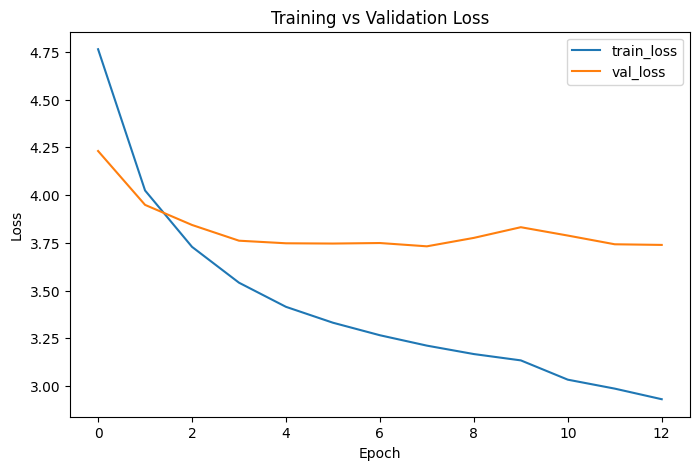

In [19]:
# Plot training curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig(os.path.join(CFG.WORKING_DIR, 'training_curve.png'), bbox_inches='tight')
plt.show()


## 9. Caption Generation: Greedy and Beam Search

The original notebook only implemented greedy decoding (always pick the single most likely next
word). That's fast but can lock the model into a suboptimal sentence early on. **Beam search**
keeps the top-`k` most promising partial captions at each step and only commits to the best full
sequence at the end — this is one of the more reliable ways to improve caption quality without
changing the trained model at all.


In [21]:
def idx_to_word(idx, tokenizer):
    return tokenizer.index_word.get(idx, None)


def generate_caption_greedy(model, image_feature, tokenizer, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length, padding='post')
        yhat = model.predict([image_feature[np.newaxis, :], seq], verbose=0)
        next_idx = int(np.argmax(yhat))
        word = idx_to_word(next_idx, tokenizer)
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()


def generate_caption_beam(model, image_feature, tokenizer, max_length, beam_width=CFG.BEAM_WIDTH):
    start_seq = tokenizer.texts_to_sequences(['startseq'])[0]
    sequences = [(start_seq, 0.0)]  # (token_ids, cumulative log-prob)

    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            last_word = idx_to_word(seq[-1], tokenizer)
            if last_word == 'endseq':
                all_candidates.append((seq, score))
                continue

            padded = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([image_feature[np.newaxis, :], padded], verbose=0)[0]
            preds = np.clip(preds, 1e-12, 1.0)
            top_idxs = np.argsort(preds)[-beam_width:]

            for idx in top_idxs:
                candidate_seq = seq + [int(idx)]
                candidate_score = score + np.log(preds[idx])
                all_candidates.append((candidate_seq, candidate_score))

        # keep top beam_width candidates overall
        ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
        sequences = ordered[:beam_width]

        if all(idx_to_word(seq[-1], tokenizer) == 'endseq' for seq, _ in sequences):
            break

    best_seq = sequences[0][0]
    words = [idx_to_word(i, tokenizer) for i in best_seq]
    words = [w for w in words if w not in ('startseq', 'endseq', None)]
    return ' '.join(words)


## 10. Evaluation: BLEU-1 to BLEU-4 + METEOR

The original notebook only reported BLEU-1 and BLEU-2. Here we add **BLEU-3, BLEU-4** (with
smoothing, since higher-order n-gram overlap is often exactly zero on short captions and would
otherwise crash the score to zero) and **METEOR**, which tends to correlate better with human
judgment than BLEU alone since it accounts for synonyms and word order more leniently.


In [22]:
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

smoothie = SmoothingFunction().method4

def evaluate_model(model, test_ids, mapping, features, tokenizer, max_length, decode='greedy'):
    actual, predicted = [], []

    for key in tqdm(test_ids, desc=f"Evaluating ({decode})"):
        refs = [c.replace('startseq', '').replace('endseq', '').strip().split()
                for c in mapping[key]]

        if decode == 'beam':
            pred = generate_caption_beam(model, features[key], tokenizer, max_length)
        else:
            pred = generate_caption_greedy(model, features[key], tokenizer, max_length)

        actual.append(refs)
        predicted.append(pred.split())

    bleu1 = corpus_bleu(actual, predicted, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

    meteor_scores = [
        meteor_score(refs, pred) for refs, pred in zip(actual, predicted)
    ]
    meteor_avg = float(np.mean(meteor_scores))

    return {
        'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-3': bleu3, 'BLEU-4': bleu4,
        'METEOR': meteor_avg,
    }


greedy_scores = evaluate_model(model, test_ids, mapping, features, tokenizer, max_length, decode='greedy')
print("Greedy decoding:")
for k, v in greedy_scores.items():
    print(f"  {k}: {v:.4f}")


Evaluating (greedy):   0%|          | 0/809 [00:00<?, ?it/s]

Greedy decoding:
  BLEU-1: 0.4894
  BLEU-2: 0.2967
  BLEU-3: 0.1809
  BLEU-4: 0.1064
  METEOR: 0.3074


In [23]:
beam_scores = evaluate_model(model, test_ids, mapping, features, tokenizer, max_length, decode='beam')
print("Beam search decoding:")
for k, v in beam_scores.items():
    print(f"  {k}: {v:.4f}")

pd.DataFrame([
    {'decoding': 'greedy', **greedy_scores},
    {'decoding': 'beam', **beam_scores},
]).to_csv(os.path.join(CFG.WORKING_DIR, 'evaluation_results.csv'), index=False)


Evaluating (beam):   0%|          | 0/809 [00:00<?, ?it/s]

Beam search decoding:
  BLEU-1: 0.5205
  BLEU-2: 0.3331
  BLEU-3: 0.2111
  BLEU-4: 0.1286
  METEOR: 0.3129


## 11. Visualize Predictions


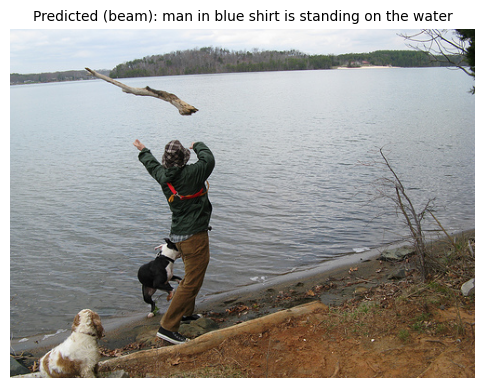

Actual captions:
 - man is standing at edge of pond with two dogs and is throwing branch is water
 - man is throwing big stick into the water so his two dogs and go fetch it
 - man is throwing log into waterway while two dogs watch
 - person in green jacket throws stick into the water for black and white dog to fetch whilst brown and white dog looks on
 - someone is at the water edge with two dogs
Predicted: man in blue shirt is standing on the water


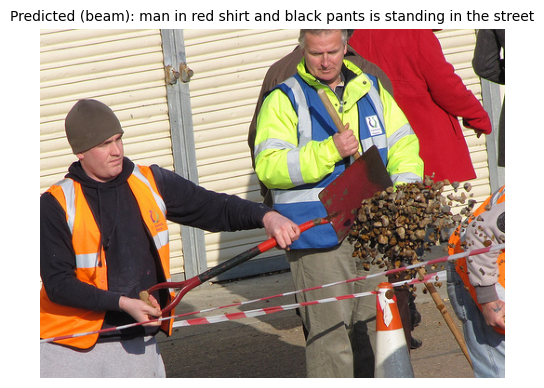

Actual captions:
 - man in an orange vest and hat is shoveling rocks while another man in yellow and blue jacket looks on
 - man with an orange vest is shoveling rocks
 - man with yellow vest shovels rocks while another man watches
 - one construction worker in an orange vest shoveling rocks while another one in blue vest watches
 - the man wearing worker vest is shoveling rocks
Predicted: man in red shirt and black pants is standing in the street


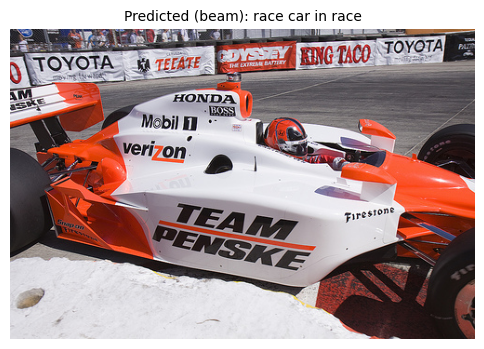

Actual captions:
 - driver is sitting in team penske race car
 - race car driver with an orange helmet sits in team penske indy car at the raceway
 - race car sits in the pits
 - race car driver getting ready for the start of the race
 - racing car marked team penske on track banners and spectators in background
Predicted: race car in race


In [24]:
from PIL import Image

def show_prediction(image_name, decode='beam'):
    image_id = image_name.split('.')[0]
    img_path = os.path.join(CFG.BASE_DIR, 'Images', image_name)
    image = Image.open(img_path)

    actual_caps = [c.replace('startseq', '').replace('endseq', '').strip() for c in mapping[image_id]]

    if decode == 'beam':
        pred = generate_caption_beam(model, features[image_id], tokenizer, max_length)
    else:
        pred = generate_caption_greedy(model, features[image_id], tokenizer, max_length)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted ({decode}): {pred}", fontsize=10, wrap=True)
    plt.show()

    print("Actual captions:")
    for c in actual_caps:
        print(" -", c)
    print("Predicted:", pred)


# Try it on a few held-out test images
sample_test_images = [f"{img_id}.jpg" for img_id in test_ids[:3]]
for img_name in sample_test_images:
    show_prediction(img_name, decode='beam')


## 12. Save Final Artifacts

Everything needed to reload and run inference later (without retraining) is saved to
`/kaggle/working/`:
- `best_model.keras` — trained model weights (already saved by `ModelCheckpoint` during training)
- `tokenizer.pkl` — fitted tokenizer
- `features.pkl` — cached image features
- `evaluation_results.csv` — BLEU/METEOR scores for greedy vs beam decoding
- `training_curve.png` — loss curves

To reuse the model later:
```python
from tensorflow.keras.models import load_model
model = load_model('/kaggle/working/best_model.keras')

with open('/kaggle/working/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
```


In [25]:
config_summary = {
    'backbone': 'InceptionV3',
    'feature_dim': CFG.FEATURE_DIM,
    'vocab_size': vocab_size,
    'max_length': max_length,
    'epochs_trained': len(history.history['loss']),
    'final_val_loss': float(history.history['val_loss'][-1]),
}

with open(os.path.join(CFG.WORKING_DIR, 'run_summary.json'), 'w') as f:
    json.dump(config_summary, f, indent=2)

print(json.dumps(config_summary, indent=2))
print("\nAll artifacts saved to:", CFG.WORKING_DIR)


{
  "backbone": "InceptionV3",
  "feature_dim": 2048,
  "vocab_size": 8769,
  "max_length": 34,
  "epochs_trained": 13,
  "final_val_loss": 3.739084243774414
}

All artifacts saved to: /kaggle/working


## Summary

| Aspect | Original | This version |
|---|---|---|
| Backbone | VGG16 (4096-d features) | InceptionV3 (2048-d features) |
| Feature extraction | One image at a time | Batched |
| Training data pipeline | Python generator | `tf.data` pipeline |
| Precision | float32 | mixed float16 |
| Text branch | Single LSTM | Bidirectional LSTM |
| Training loop | Fixed 20 epochs | EarlyStopping + LR scheduling + checkpointing |
| Decoding | Greedy only | Greedy + Beam search |
| Evaluation | BLEU-1, BLEU-2 | BLEU-1–4 (smoothed) + METEOR |
| Splits | Train/Test (90/10) | Train/Val/Test |

**Ideas for further improvement**, if you want to push this further later:
- Add a **Bahdanau/Luxury attention** mechanism over spatial CNN feature maps instead of a single pooled vector (bigger jump in quality, more code)
- Try **CLIP** or **BLIP** image encoders, which are far stronger than ImageNet-pretrained CNNs for this task
- Use **scheduled sampling** during training to reduce train/inference mismatch
- Fine-tune the top layers of InceptionV3 instead of freezing it entirely (more compute, can help if you switch to Flickr30k/MS-COCO)
